AIMS 5702 Artificial Intelligence in Practice (Fall 2026-27)

**AIMS 5702 Assignment 1**

Please complete this Colab notebook and:

* Download it as **both** an `.ipynb` file and a `.pdf` file.
* Submit **both** files to Blackboard.

**No GPU is required.** CPU runtime is sufficient.

**Deadline of submission**: 26th September, 2026 (Saturday)

Unless a question explicitly says otherwise, do not use `torch.matmul`, `torch.mm`, or the `@` operator in your implementation.


In [38]:
#@title Import

import torch
import math
import numpy as np
from typing import Optional
import scipy.interpolate

In [39]:
#@title Utilities

def is_same_tensor(result: torch.Tensor,
                   ref: torch.Tensor,
                   tol: Optional[float]=None) -> bool:
  """
  Check if two tensors are the same.

  Args:
    result: Results by your code.
    ref: Ground truth result.

  Return:
    Whether result and ref are the same.
  """
  if (not isinstance(result, torch.Tensor) or
      not isinstance(ref, torch.Tensor)):
    return False
  if result.dtype != ref.dtype:
    result = result.to(ref.dtype)
  if tol is not None:
    return torch.allclose(result, ref, rtol=0, atol=tol)
  else:
    return torch.equal(result, ref)

# Question 1. Pairwise Dot-Product Matrix


Given two 2D tensors `x` and `y` with shapes `(m, k)` and `(n, k)`, compute the pairwise dot-product matrix `z` with shape `(m, n)`, where

$$z_{ij} = \sum_{t=1}^{k} x_{it} y_{jt}.$$

Equivalently, the reference result is `x @ y.T`. In this assignment, you must implement it **without** calling `torch.matmul`, `torch.mm`, or using `@` inside your functions.

If either input is not a 2D tensor, or if the feature dimensions do not match, return `None`.

You will implement it in three ways.


First, implement it using **exactly two nested Python `for` loops**.

Hint: each output entry is a dot product; `torch.sum` may be useful.


In [40]:
#@title Q1.1. pairwise_dot_forloop

def pairwise_dot_forloop(
    x: torch.Tensor,
    y: torch.Tensor
) -> Optional[torch.Tensor]:
  """
  Compute all pairwise dot products using exactly two nested Python loops.

  Args:
    x: 2D tensor with shape (m, k).
    y: 2D tensor with shape (n, k).

  Returns:
    A tensor with shape (m, n), or None for invalid input shapes.
  """
  if not isinstance(x, torch.Tensor) or not isinstance(y, torch.Tensor):
    return None
  
  if x.ndim != 2 or y.ndim != 2 or x.shape[1] != y.shape[1]:
    return None

  m, n = x.shape[0], y.shape[0]
  result = torch.zeros((m, n), dtype=torch.promote_types(x.dtype, y.dtype), device=x.device)
  for i in range(m):
    for j in range(n):
      result[i, j] = torch.sum(x[i] * y[j])

  return result


**Q1.1 explanation.** Each output entry is the dot product of one row of `x` and one row of `y`. The outer loop selects the row of `x`, and the inner loop selects the row of `y`; `torch.sum` reduces the elementwise product over the features. There are exactly two nested Python loops. Time complexity is O(mnk), and the output uses O(mn) space.


Second, implement the same operation using only PyTorch tensor/vector operations. **No Python `for` loop is allowed.**

Hints: broadcasting and `torch.sum` are sufficient.


In [41]:
#@title Q1.2. pairwise_dot_nofor

def pairwise_dot_nofor(
    x: torch.Tensor,
    y: torch.Tensor
) -> Optional[torch.Tensor]:
  """
  Compute all pairwise dot products without Python loops.

  Args:
    x: 2D tensor with shape (m, k).
    y: 2D tensor with shape (n, k).

  Returns:
    A tensor with shape (m, n), or None for invalid input shapes.
  """
  if not isinstance(x, torch.Tensor) or not isinstance(y, torch.Tensor):
    return None
  
  if x.ndim != 2 or y.ndim != 2 or x.shape[1] != y.shape[1]:
    return None

  return (x.unsqueeze(1) * y.unsqueeze(0)).sum(dim=2)


**Q1.2 explanation.** Adding singleton dimensions gives shapes `(m, 1, k)` and `(1, n, k)`. Broadcasting computes all row-pair products with shape `(m, n, k)`, then summing dimension 2 gives `(m, n)`. This uses no Python loops. Time complexity is O(mnk); the broadcast product uses O(mnk) temporary memory.


Third, implement the same operation using `torch.einsum`.


In [42]:
#@title Q1.3. pairwise_dot_einsum

def pairwise_dot_einsum(
    x: torch.Tensor,
    y: torch.Tensor
) -> Optional[torch.Tensor]:
  """
  Compute all pairwise dot products using torch.einsum.

  Args:
    x: 2D tensor with shape (m, k).
    y: 2D tensor with shape (n, k).

  Returns:
    A tensor with shape (m, n), or None for invalid input shapes.
  """
  if not isinstance(x, torch.Tensor) or not isinstance(y, torch.Tensor):
    return None

  if x.ndim != 2 or y.ndim != 2 or x.shape[1] != y.shape[1]:
    return None

  return torch.einsum('it,jt->ij', x, y)


**Q1.3 explanation.** In `torch.einsum('it,jt->ij', x, y)`, `i` and `j` identify rows of the two inputs, and the shared index `t` is summed over. The output is the same `(m, n)` pairwise dot-product matrix. All three implementations return `None` for invalid input dimensions or mismatched feature counts.


**Testing**

Please run the following blocks before submission, but **do not change them**. Modified test blocks receive no mark for this question.


In [43]:
#@title Test 1

m_list = [2, 3, 8, 25]
n_list = [4, 1, 7, 30]
k_list = [2, 5, 11, 40]

torch.manual_seed(2026)
for i, (m, n, k) in enumerate(zip(m_list, n_list, k_list)):
  x = torch.randint(-20, 21, size=(m, k))
  y = torch.randint(-20, 21, size=(n, k))
  z_ref = x @ y.T
  z_forloop = pairwise_dot_forloop(x, y)
  z_nofor = pairwise_dot_nofor(x, y)
  z_einsum = pairwise_dot_einsum(x, y)
  assert is_same_tensor(z_ref, z_forloop)
  assert is_same_tensor(z_ref, z_nofor)
  assert is_same_tensor(z_ref, z_einsum)
  print(f'{i}-th test succeeds')


0-th test succeeds
1-th test succeeds
2-th test succeeds
3-th test succeeds


In [44]:
#@title Test 2

m, n, k = 180, 220, 320

torch.manual_seed(2026)
x = torch.rand(size=(m, k), dtype=torch.float32)
y = torch.rand(size=(n, k), dtype=torch.float32)
z_ref = x @ y.T
z_nofor = pairwise_dot_nofor(x, y)
z_einsum = pairwise_dot_einsum(x, y)
assert is_same_tensor(z_ref, z_nofor, 1e-4)
assert is_same_tensor(z_ref, z_einsum, 1e-4)
print('test succeeds')


test succeeds


In [45]:
#@title Test 3

x = torch.rand(3, 5)
y = torch.rand(2, 4)
assert pairwise_dot_forloop(x, y) is None
assert pairwise_dot_nofor(x, y) is None
assert pairwise_dot_einsum(x, y) is None

x = torch.rand(3, 5, 1)
y = torch.rand(2, 5)
assert pairwise_dot_forloop(x, y) is None
assert pairwise_dot_nofor(x, y) is None
assert pairwise_dot_einsum(x, y) is None

x = torch.rand(5)
y = torch.rand(2, 5)
assert pairwise_dot_forloop(x, y) is None
assert pairwise_dot_nofor(x, y) is None
assert pairwise_dot_einsum(x, y) is None

print('test succeeds')


test succeeds


# Question 2. Bilinear Interpolation with Normalized Coordinates


Next, implement 2D bilinear interpolation. The interpolation rule is the standard bilinear interpolation described here:

https://en.wikipedia.org/wiki/Bilinear_interpolation

In this version of the assignment, query coordinates are **normalized**: both `x_ref_list` and `y_ref_list` contain values in `[0, 1]`. A normalized coordinate `(0, 0)` refers to the top-left grid point and `(1, 1)` refers to the bottom-right grid point.


For a value grid `v` of shape `(h, w)`, convert normalized coordinates to grid coordinates by

`x_grid = x_ref * (w - 1)` and `y_grid = y_ref * (h - 1)`.

Then apply ordinary bilinear interpolation on the four neighboring grid values.


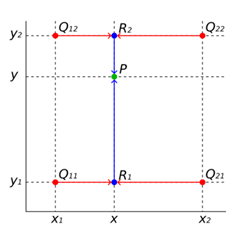

Given one or more normalized query locations `(x_ref, y_ref)`, your function should return the interpolated values at those locations. Query lists must be 1D tensors of the same length, and all coordinates must lie in `[0, 1]`; otherwise return `None`.


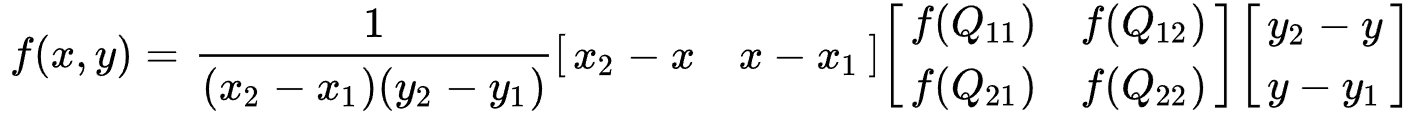

For your information, here is a simple loop-based reference implementation for the normalized-coordinate version.


In [46]:
#@title Reference implementation

def interp2d_forloop(
    v: torch.Tensor,
    x_ref_list: torch.Tensor,
    y_ref_list: torch.Tensor,
) -> Optional[torch.Tensor]:
  # Basic input validation.
  if (not isinstance(v, torch.Tensor) or not isinstance(x_ref_list, torch.Tensor) or
      not isinstance(y_ref_list, torch.Tensor)):
    return None
  if v.ndim != 2 or x_ref_list.ndim != 1 or y_ref_list.ndim != 1:
    return None
  if x_ref_list.shape[0] != y_ref_list.shape[0] or v.shape[0] == 0 or v.shape[1] == 0:
    return None
  if (torch.any(x_ref_list < 0) or torch.any(x_ref_list > 1) or
      torch.any(y_ref_list < 0) or torch.any(y_ref_list > 1)):
    return None

  h, w = v.shape
  nlen = x_ref_list.shape[0]
  out_dtype = v.dtype if v.is_floating_point() else torch.float32
  v_ref = torch.zeros(nlen, dtype=out_dtype, device=v.device)
  vv = v.to(out_dtype)

  for i in range(nlen):
    x_ref = x_ref_list[i].to(v.device, dtype=out_dtype) * (w - 1)
    y_ref = y_ref_list[i].to(v.device, dtype=out_dtype) * (h - 1)
    x1 = int(torch.floor(x_ref).item())
    y1 = int(torch.floor(y_ref).item())
    x2 = min(x1 + 1, w - 1)
    y2 = min(y1 + 1, h - 1)
    wx = x_ref - x1
    wy = y_ref - y1
    f11 = vv[y1, x1]
    f12 = vv[y1, x2]
    f21 = vv[y2, x1]
    f22 = vv[y2, x2]
    v_ref[i] = (f11 * (1 - wx) * (1 - wy) +
                f12 * wx * (1 - wy) +
                f21 * (1 - wx) * wy +
                f22 * wx * wy)
  return v_ref


Now it is your turn. Implement the normalized-coordinate interpolation using PyTorch tensor operations, **without any Python `for` loop** and without calling a third-party interpolation routine.


In [47]:
#@title Q2.1. interp2d_nofor

def interp2d_nofor(
    v: torch.Tensor,
    x_ref_list: torch.Tensor,
    y_ref_list: torch.Tensor,
) -> Optional[torch.Tensor]:
  """
  Bilinear interpolation at normalized coordinates, without Python loops.

  Args:
    v: 2D value grid with shape (h, w).
    x_ref_list: 1D tensor of normalized x coordinates in [0, 1].
    y_ref_list: 1D tensor of normalized y coordinates in [0, 1].

  Returns:
    1D tensor of interpolated values, or None for invalid inputs.
  """
  if (not isinstance(v, torch.Tensor) or
      not isinstance(x_ref_list, torch.Tensor) or
      not isinstance(y_ref_list, torch.Tensor)):
    return None
  
  if v.ndim != 2 or x_ref_list.ndim != 1 or y_ref_list.ndim != 1:
    return None
  
  if (x_ref_list.shape[0] != y_ref_list.shape[0] or
      v.shape[0] == 0 or v.shape[1] == 0):
    return None
  

  if x_ref_list.is_complex() or y_ref_list.is_complex():
    return None

  if (not torch.isfinite(x_ref_list).all() or
      not torch.isfinite(y_ref_list).all() or
      torch.any(x_ref_list < 0) or torch.any(x_ref_list > 1) or
      torch.any(y_ref_list < 0) or torch.any(y_ref_list > 1)):
    return None

  h, w = v.shape
  out_dtype = v.dtype if v.is_floating_point() else torch.float32
  vv = v.to(dtype=out_dtype)
  x_grid = x_ref_list.to(device=v.device, dtype=out_dtype) * (w - 1)
  y_grid = y_ref_list.to(device=v.device, dtype=out_dtype) * (h - 1)

  x1 = torch.floor(x_grid).to(torch.long)
  y1 = torch.floor(y_grid).to(torch.long)
  x2 = (x1 + 1).clamp(max=w - 1)
  y2 = (y1 + 1).clamp(max=h - 1)
  wx = x_grid - x1
  wy = y_grid - y1

  f11 = vv[y1, x1]
  f12 = vv[y1, x2]
  f21 = vv[y2, x1]
  f22 = vv[y2, x2]
  return (f11 * (1 - wx) * (1 - wy) +
          f12 * wx * (1 - wy) +
          f21 * (1 - wx) * wy +
          f22 * wx * wy)


**Q2.1 explanation.** Convert each normalized coordinate to a grid location using `x_grid = x_ref * (w - 1)` and `y_grid = y_ref * (h - 1)`. The first tensor index is the row (y), and the second is the column (x). Take the floor to find the left/top neighbor and clamp the right/bottom neighbor to the grid boundary. The fractional offsets `wx` and `wy` give the four weights: `(1-wx)(1-wy)`, `wx(1-wy)`, `(1-wx)wy`, and `wx*wy`. Their weighted sum is the interpolated value. Tensor indexing evaluates all queries together without Python loops or third-party interpolation calls. Boundary coordinates, single-row/single-column grids, and empty query lists are supported. Invalid shapes, lengths, empty grids, or out-of-range/non-finite coordinates return `None`. Integer grids produce floating-point results. For N queries, interpolation takes O(N) time and O(N) working space, with an additional O(hw) conversion when the grid has integer values.


**Testing**

Please run the following blocks before submission, but **do not change them**. Modified test blocks receive no mark for this question.


In [48]:
#@title Test 1

torch.manual_seed(2026)
h, w, vlen = 80, 60, 40
v = torch.rand(h, w, dtype=torch.float32)
x = torch.linspace(0, w - 1, w)
y = torch.linspace(0, h - 1, h)

interp = scipy.interpolate.RegularGridInterpolator(
    (y.numpy(), x.numpy()), v.numpy(), method='linear')
x_ref = torch.rand(vlen)
y_ref = torch.rand(vlen)
xy_ref = np.stack((y_ref.numpy() * (h - 1),
                   x_ref.numpy() * (w - 1)), axis=1)
v_ref = interp(xy_ref)

v_ref_forloop = interp2d_forloop(v, x_ref, y_ref)
v_ref_nofor = interp2d_nofor(v, x_ref, y_ref)

assert is_same_tensor(torch.tensor(v_ref), v_ref_forloop, tol=1e-5)
assert is_same_tensor(torch.tensor(v_ref), v_ref_nofor, tol=1e-5)
print('test succeeds')


test succeeds


In [49]:
#@title Test 2

# Exact corner and center checks.
v = torch.tensor([[0.0, 2.0], [4.0, 6.0]])
x_ref = torch.tensor([0.0, 1.0, 0.5])
y_ref = torch.tensor([0.0, 1.0, 0.5])
expected = torch.tensor([0.0, 6.0, 3.0])
assert is_same_tensor(interp2d_nofor(v, x_ref, y_ref), expected, tol=1e-6)

# Invalid shape / length / range checks.
v = torch.rand(10, 4)
assert interp2d_nofor(v, torch.tensor([0.2]), torch.tensor([0.2, 0.4])) is None
assert interp2d_nofor(v, torch.tensor([[0.2, 0.3]]), torch.tensor([0.2, 0.3])) is None
assert interp2d_nofor(v, torch.tensor([1.2]), torch.tensor([0.5])) is None
assert interp2d_nofor(v, torch.tensor([0.5]), torch.tensor([-0.1])) is None

print('test succeeds')


test succeeds
